In [1]:
import jax.numpy as jnp
import numpy as np
import jax.nn as jnn

import equinox as eqx

from models import *

In [2]:
from exp import exp as ex

In [3]:
model = ex.model
EX = ex.EX
steps = ex.steps

ts_eval = ex.ts_eval

exp_name = ex.exp_name
path = f"results/{exp_name}"
param_path = f"{path}/model_parameter/model_step_{steps:05d}.eqx"
loss_list = np.load(f"{path}/loss_list.npy")

EX.model = eqx.tree_deserialise_leaves(
    param_path,
    EX.model
)

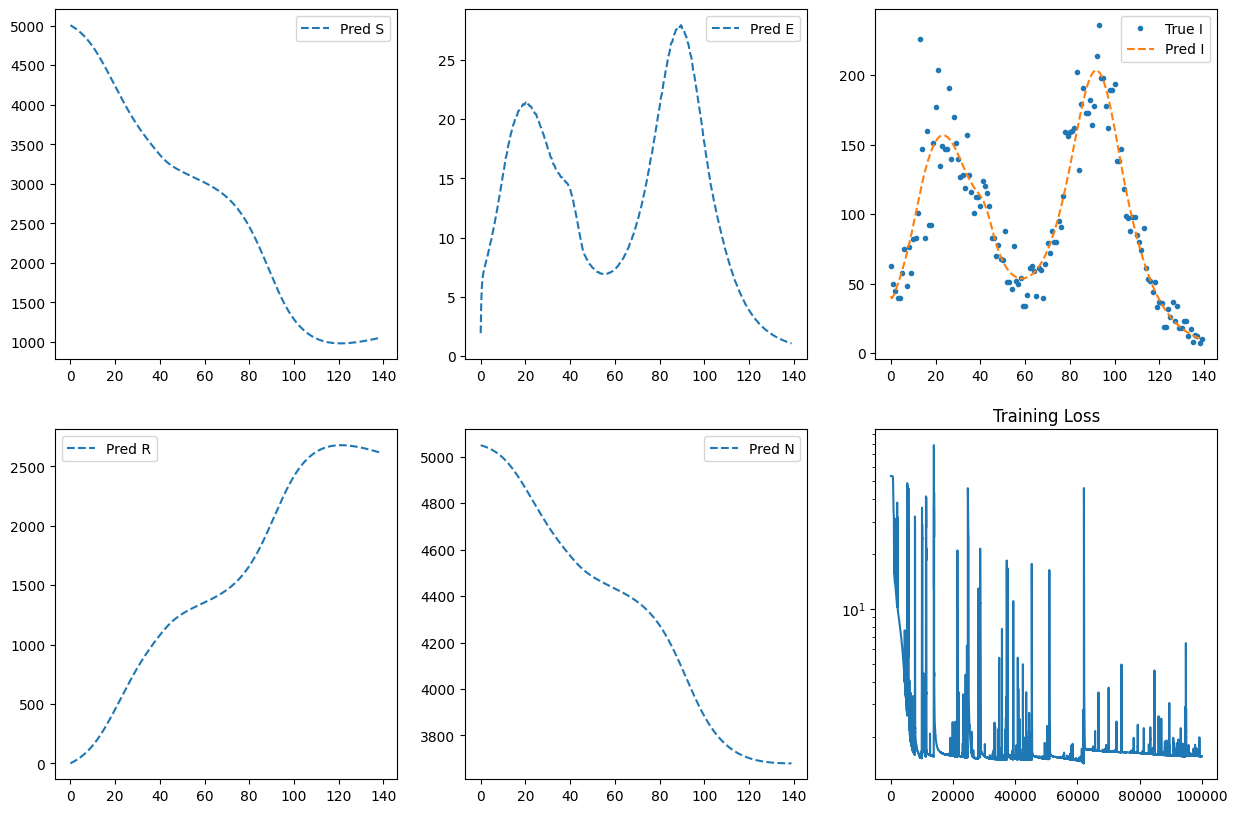

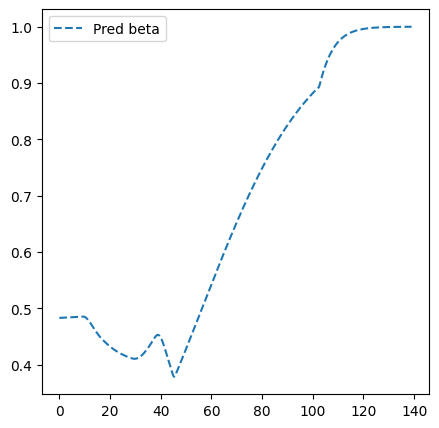

In [4]:
model.Evaluation(EX, ts_eval, loss_list, viz_data=False)

In [5]:
S0, E0, I0, R0 = jnn.softplus(EX.model.y0)
print(f"Initial value - S0:{S0:.0f}, E0:{E0:.0f}, I0:{I0:.0f}, R0:{R0:.0f}")

ss, kk, aa, gg = jnn.softplus(EX.model.parameter)
print(f"sigma:{ss:.7f}, kappa:{kk:.7f}, alpha:{aa:.7f}, gamma:{gg:.7f}")

Initial value - S0:5007, E0:2, I0:41, R0:0
sigma:2.4911184, kappa:0.1990889, alpha:0.1146744, gamma:0.2159609
